# Week 2 · Day 3 — Full universe: MLP vs LSTM, as portfolios

Days 1 and 2 (in `03-form-prediction-to-portfolio/mlp.ipynb` and `lstm.ipynb`) each
trained on the **full universe already** — every symbol in `data/egx`, pooled — so
today isn't a bigger dataset, it's a **head-to-head**: same universe, same test
period, same benchmark, MLP against LSTM, judged the same honest way the pivot
notebook taught you to judge anything — not by one lucky run, but across a sweep
of configurations and a spread of seeds.

Nothing here is rebuilt from scratch. Every piece — `build_pooled_dataset`,
`build_pooled_sequences`, `MLP`, `LSTMRegressor`, `train_model`,
`predictions_to_weights`, `model_to_strategy`, `run_backtest`, `report`,
`information_coefficient` — already exists in `src/tradinglab`, graduated from
days 1, 2, and the pivot notebook. Today just wires them together and asks harder
questions of them:

1. Rebuild the full-universe dataset (both flat and sequence form).
2. Train an MLP and an LSTM on it, reusing the given training loop.
3. Turn each model's predictions into portfolio weights.
4. Backtest both, plot them against the benchmark, and see who wins.
5. Sweep LSTM hyperparameters and find the best config by final equity.
6. Reseed the winner 6 times and check whether "best" survives a coin flip.

## 1. Rebuild the full-universe dataset

Same feed, same feature columns, same time-based split as `mlp.ipynb` and
`lstm.ipynb`: `build_pooled_dataset` for the MLP's flat rows, `build_pooled_sequences`
for the LSTM's windows. Both pool **every** stock in `data/egx`, and both mask each
stock's rows against `split_day` *before* pooling — so no stock ever leaks a
late-period row into training (see the docstrings in `features.py` if you want the
full reasoning).

**A note before you run this:** the cell below prints a `RuntimeWarning: invalid
value encountered in divide` from `features.py:64`
(`volume_ratio = volume / vol_avg20`). Some EGX stocks have zero-volume days, so
`0 / 0 -> nan` for a few entries. It looks alarming, but check the `cols` list in
`feature_columns` — `volume_ratio` is commented out there, so this NaN is computed
and immediately thrown away; it never enters `X`. The assertion right after the
warning proves it: no NaNs make it into the dataset.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np, json
import matplotlib.pyplot as plt
import torch
os.makedirs('dashboard/data', exist_ok=True)

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset, build_pooled_sequences

EPOCHS = 150
TOP_K = 4
SEQ_LEN = 10
HIDDEN = 32

feed = DataFeed.from_dir('data/egx')   # full universe -- every symbol in data/egx
print('universe:', feed.n_assets, 'symbols |', feed.n_days, 'trading days')

split_day = int(feed.n_days * 0.7)
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)
Xs_train, ys_train, Xs_test, ys_test = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)
n_features = X_train.shape[1]

# the RuntimeWarning above comes from a column that's computed but never used --
# confirm it doesn't leak into the actual training data
assert not np.isnan(X_train).any() and not np.isnan(X_test).any()
assert not np.isnan(Xs_train).any() and not np.isnan(Xs_test).any()

print('flat      :', len(X_train), 'train /', len(X_test), 'test |', n_features, 'features')
print('sequences :', Xs_train.shape, 'train /', Xs_test.shape, 'test')

universe: 34 symbols | 1159 trading days


/Users/judyhedayah/Desktop/2026-orion-1/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


flat      : 26588 train / 11798 test | 5 features
sequences : (26248, 10, 5) train / (11458, 10, 5) test


## 2. Train the MLP

Same `MLP` class and `train_model` loop as day 1 — nothing new, just pointed at
the full-universe table instead of a single stock.

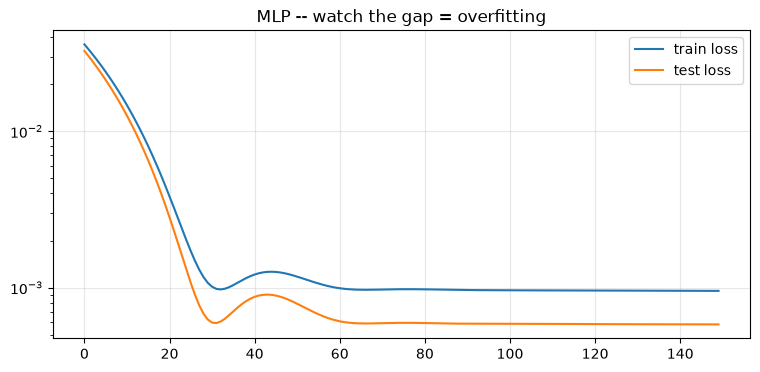

final train 0.00095 | test 0.00058


In [2]:
torch.manual_seed(0)
from tradinglab.models import MLP
from tradinglab.ml import train_model, predict

mlp = MLP(n_features, hidden=HIDDEN)
mlp_history = train_model(mlp, X_train, y_train, X_test, y_test, epochs=EPOCHS)

plt.figure(figsize=(9, 4))
plt.plot(mlp_history['train'], label='train loss')
plt.plot(mlp_history['test'], label='test loss')
plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('MLP -- watch the gap = overfitting')
plt.show()
print('final train %.5f | test %.5f' % (mlp_history['train'][-1], mlp_history['test'][-1]))

## 3. Train the LSTM

Same `LSTMRegressor` class and the same `train_model` loop -- it doesn't care
whether the model is an MLP or an LSTM, only that shapes match.

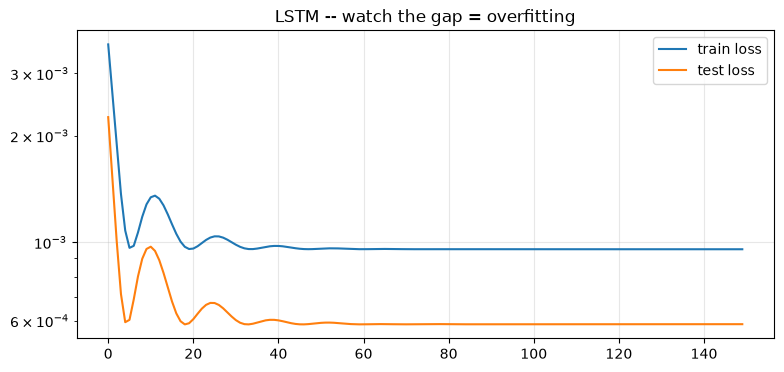

final train 0.00096 | test 0.00059


In [3]:
torch.manual_seed(0)
from tradinglab.models import LSTMRegressor

lstm = LSTMRegressor(n_features=n_features, hidden=HIDDEN)
lstm_history = train_model(lstm, Xs_train, ys_train, Xs_test, ys_test, epochs=EPOCHS)

plt.figure(figsize=(9, 4))
plt.plot(lstm_history['train'], label='train loss')
plt.plot(lstm_history['test'], label='test loss')
plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('LSTM -- watch the gap = overfitting')
plt.show()
print('final train %.5f | test %.5f' % (lstm_history['train'][-1], lstm_history['test'][-1]))

## 4. Predictions -> portfolio weights

`predictions_to_weights` and `model_to_strategy` are already graduated in
`src/tradinglab/strategies/predictor.py` from day 1 -- reused as-is, not rewritten.

The MLP only wants **today's** row (`observation[:, -1, :]`), which is exactly what
`model_to_strategy` does. The LSTM wants the **whole window**, so it needs its own
wrapper -- written the same way `03-form-prediction-to-portfolio/lstm.ipynb` did it:
slice the last `seq_len` steps out of the observation, predict, and reuse
`predictions_to_weights` for the actual weighting.

In [4]:
from tradinglab.strategies.predictor import predictions_to_weights, model_to_strategy

def lstm_to_strategy(model, seq_len, top_k=2):
    def strategy(observation):
        window = observation[:, -seq_len:, :]              # take only the last seq_len days
        preds = predict(model, window.astype('float32'))
        return predictions_to_weights(preds, top_k)
    return strategy

mlp_strategy = model_to_strategy(mlp, top_k=TOP_K)
lstm_strategy = lstm_to_strategy(lstm, seq_len=SEQ_LEN, top_k=TOP_K)

## 5. Backtest both on the real backtester, same test period

Same simulator, same benchmark, same start day for both -- the only thing that
differs is which model is picking the weights.

/Users/judyhedayah/Desktop/2026-orion-1/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


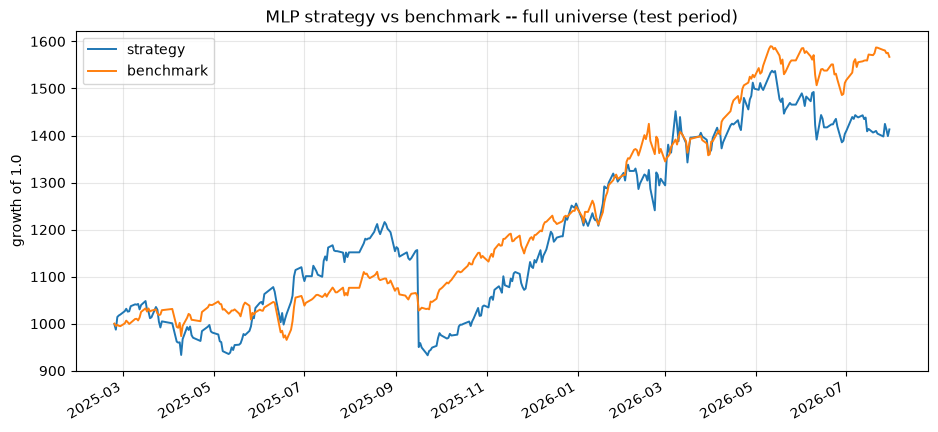

total return   : +41.3%
sharpe         : 1.04
max drawdown   : 23.3%
final value    : 1413.01   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 154 EGP


In [5]:
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.report import report

sim = PortfolioSimulator(feed)
split = split_day

result_mlp = run_backtest(sim, mlp_strategy, lookback=30, start=split)
report(result_mlp, title='MLP strategy vs benchmark -- full universe (test period)', start_capital=1000.0)

json.dump({'portfolio': [round(x, 4) for x in result_mlp['portfolio'].tolist()],
           'benchmark': [round(x, 4) for x in result_mlp['benchmark'].tolist()],
           'dates': [d.strftime('%Y-%m-%d') for d in result_mlp['dates']]},
          open('dashboard/data/day3_mlp_equity.json', 'w'))

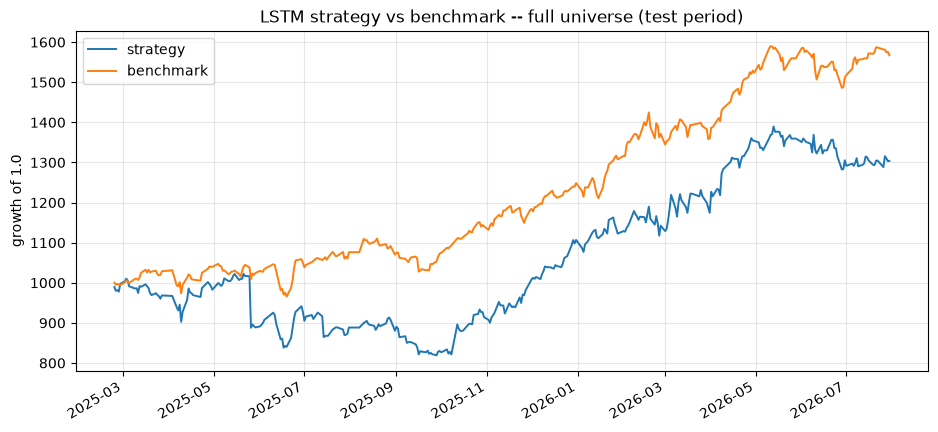

total return   : +30.4%
sharpe         : 0.90
max drawdown   : 19.9%
final value    : 1303.91   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 263 EGP


In [6]:
result_lstm = run_backtest(sim, lstm_strategy, lookback=30, start=split)
report(result_lstm, title='LSTM strategy vs benchmark -- full universe (test period)', start_capital=1000.0)

json.dump({'portfolio': [round(x, 4) for x in result_lstm['portfolio'].tolist()],
           'benchmark': [round(x, 4) for x in result_lstm['benchmark'].tolist()],
           'dates': [d.strftime('%Y-%m-%d') for d in result_lstm['dates']]},
          open('dashboard/data/day3_lstm_equity.json', 'w'))

### The honest comparison -- both curves, one chart

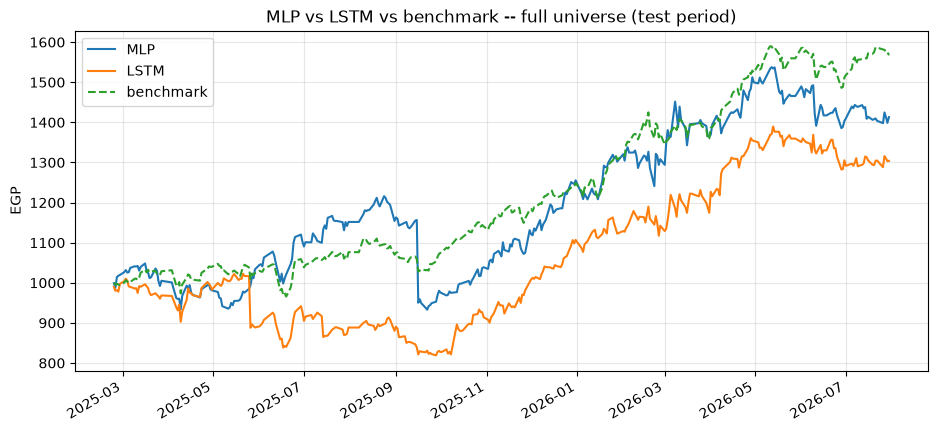

MLP final  :        1,413 EGP  -- beat benchmark: no
LSTM final :        1,304 EGP  -- beat benchmark: no
benchmark  :        1,567 EGP

MLP beat the other model by 109 EGP.


In [7]:
START = 1000.0
dates = result_mlp['dates']

plt.figure(figsize=(11, 5))
plt.plot(dates, result_mlp['portfolio'] * START, label='MLP')
plt.plot(dates, result_lstm['portfolio'] * START, label='LSTM')
plt.plot(dates, result_mlp['benchmark'] * START, label='benchmark', linestyle='--')
plt.legend(); plt.grid(alpha=.3); plt.ylabel('EGP')
plt.title('MLP vs LSTM vs benchmark -- full universe (test period)')
plt.gcf().autofmt_xdate()
plt.show()

mlp_final = result_mlp['portfolio'][-1] * START
lstm_final = result_lstm['portfolio'][-1] * START
bench_final = result_mlp['benchmark'][-1] * START

print(f'MLP final  : {mlp_final:12,.0f} EGP  -- beat benchmark: {"YES" if mlp_final > bench_final else "no"}')
print(f'LSTM final : {lstm_final:12,.0f} EGP  -- beat benchmark: {"YES" if lstm_final > bench_final else "no"}')
print(f'benchmark  : {bench_final:12,.0f} EGP')

winner = 'LSTM' if lstm_final > mlp_final else 'MLP'
print(f'\n{winner} beat the other model by {abs(lstm_final - mlp_final):,.0f} EGP.')

## 6. Experiment -- sweep the LSTM's hyperparameters

One `(hidden, seq_len)` pair means one retrain (a new sequence dataset for a new
`seq_len`, a new model for a new `hidden`); `top_k` doesn't need a retrain at all --
it only changes how the *same* trained model's predictions get turned into weights.
So the loop below trains once per `(hidden, seq_len)` and reuses that model across
every `top_k`.

**Fewer epochs on purpose:** `SWEEP_EPOCHS` is lower than the `EPOCHS` used above so
the whole grid finishes in a couple of minutes. The point of this sweep is to *rank*
configs against each other, not to fully converge every one of them -- the winner
gets retrained properly in the next section.

Sequence datasets are cached per `seq_len` so they're only built once, not once per
hidden size.

In [8]:
HIDDEN_GRID = [16, 32]
SEQ_LEN_GRID = [5, 10, 20]
TOPK_GRID = [3, 5]
SWEEP_EPOCHS = 60

seq_cache = {}
def get_sequences(seq_len):
    if seq_len not in seq_cache:
        seq_cache[seq_len] = build_pooled_sequences(feed, split_day, seq_len=seq_len)
    return seq_cache[seq_len]

sweep_rows = []
print(f'{"hidden":>6s} {"seq_len":>7s} {"top_k":>5s} {"final equity (EGP)":>19s}')
for seq_len in SEQ_LEN_GRID:
    Xtr_sw, ytr_sw, Xte_sw, yte_sw = get_sequences(seq_len)
    for hidden in HIDDEN_GRID:
        torch.manual_seed(0)
        m = LSTMRegressor(n_features=Xtr_sw.shape[2], hidden=hidden)
        train_model(m, Xtr_sw, ytr_sw, Xte_sw, yte_sw, epochs=SWEEP_EPOCHS)
        for top_k in TOPK_GRID:
            strat = lstm_to_strategy(m, seq_len=seq_len, top_k=top_k)
            res = run_backtest(sim, strat, lookback=30, start=split)
            final_equity = res['portfolio'][-1] * START
            sweep_rows.append({'hidden': hidden, 'seq_len': seq_len, 'top_k': top_k,
                                'final_equity': final_equity})
            print(f'{hidden:6d} {seq_len:7d} {top_k:5d} {final_equity:19,.0f}')

best = max(sweep_rows, key=lambda r: r['final_equity'])
print(f"\nbest config -> hidden={best['hidden']}  seq_len={best['seq_len']}  "
      f"top_k={best['top_k']}  final equity {best['final_equity']:,.0f} EGP")

hidden seq_len top_k  final equity (EGP)


    16       5     3               1,412
    16       5     5               1,339


    32       5     3               1,138
    32       5     5               1,224


    16      10     3               1,341
    16      10     5               1,307


    32      10     3               1,082
    32      10     5               1,472


    16      20     3               1,383
    16      20     5               1,344


    32      20     3               1,134


    32      20     5               1,508

best config -> hidden=32  seq_len=20  top_k=5  final equity 1,508 EGP


## 7. Robustness check -- does the winner survive a reseed?

The pivot notebook's whole point: one good run proves nothing. Retrain the winning
`(hidden, seq_len, top_k)` config 6 times -- same data, same architecture, same
epochs, **only `torch.manual_seed` changes** -- and look at both the win rate against
the benchmark and the `information_coefficient` (reused from `metrics.py`, the exact
function `pivot.ipynb` graduated there) each time.

In [9]:
from tradinglab.metrics import information_coefficient

BEST_HIDDEN, BEST_SEQ_LEN, BEST_TOPK = best['hidden'], best['seq_len'], best['top_k']
Xtr_best, ytr_best, Xte_best, yte_best = get_sequences(BEST_SEQ_LEN)

print(f'{"seed":>5s} {"IC":>8s} {"strategy (EGP)":>15s} {"benchmark (EGP)":>16s}  beat?')
robust_rows = []
for seed in range(6):
    torch.manual_seed(seed)
    m = LSTMRegressor(n_features=Xtr_best.shape[2], hidden=BEST_HIDDEN)
    train_model(m, Xtr_best, ytr_best, Xte_best, yte_best, epochs=EPOCHS)
    seed_ic = information_coefficient(predict(m, Xte_best), yte_best)
    strat = lstm_to_strategy(m, seq_len=BEST_SEQ_LEN, top_k=BEST_TOPK)
    res = run_backtest(sim, strat, lookback=30, start=split)
    final, bench = res['portfolio'][-1] * START, res['benchmark'][-1] * START
    beat = final > bench
    robust_rows.append((seed, seed_ic, final, bench, beat))
    print(f'{seed:5d} {seed_ic:+8.3f} {final:15,.0f} {bench:16,.0f}  {"YES" if beat else "no"}')

wins = sum(r[4] for r in robust_rows)
print(f'\nwinning config beat the benchmark in {wins}/6 runs -- '
      f'same data, same architecture, only the seed changed.')

 seed       IC  strategy (EGP)  benchmark (EGP)  beat?


    0   -0.007           1,548            1,567  no


    1   -0.006           1,368            1,567  no


    2   -0.020           1,305            1,567  no


    3   -0.015           1,309            1,567  no


    4   -0.024           1,436            1,567  no


    5   +0.009           1,498            1,567  no

winning config beat the benchmark in 0/6 runs -- same data, same architecture, only the seed changed.


## 8. Verdict

- MLP vs LSTM was decided on one, honest, identical test period -- see section 5
  for who won and by how much.
- The hyperparameter sweep in section 6 picked the best `(hidden, seq_len, top_k)`
  by final equity alone -- a single number, on a single test window.
- Section 7 is the check on that number: if the win rate above isn't close to 6/6,
  "best config" was mostly a description of one lucky test window, not a
  repeatable edge -- the same lesson the pivot notebook already taught you, now
  applied to a model *and* its hyperparameters instead of just its seed.

**On the `RuntimeWarning`:** confirmed harmless. `volume_ratio` is computed in
`feature_columns` (`features.py:64`) but commented out of the `cols` list that
actually becomes `X`, so the `0/0 -> nan` it produces for a few zero-volume EGX
days never reaches the dataset -- the `assert`s in section 1 check this directly.
If `volume_ratio` is ever uncommented to add it as a real feature, that divide
will need a guard (e.g. `np.where(vol_avg20 > 0, volume / vol_avg20, 0.0)`)
before it's safe to use.

## 9. An explicit equal-weight benchmark

`PortfolioSimulator`'s built-in `benchmark` curve (used in every `report()` call
above) already *is* an equal-weight buy-and-hold basket, computed directly as
`feed.returns.mean(axis=1)` (see `simulator.py`). This section makes that
explicit: an actual `strategy(observation) -> weights` function that returns
`1/n_assets` every day, run through the exact same `run_backtest` pipeline as
every model below, so it produces a `result_equal_weight` dict directly
comparable to `result_mlp` / `result_lstm` (not just a curve borrowed from
inside someone else's result).

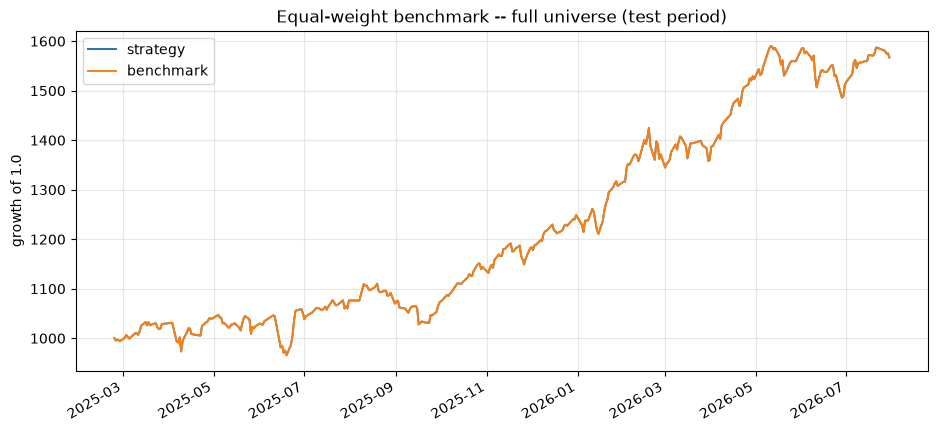

total return   : +56.7%
sharpe         : 2.13
max drawdown   : 7.8%
final value    : 1567.20   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 0 EGP
confirmed: explicit equal-weight strategy matches the simulator's built-in benchmark curve.


In [10]:
def equal_weight_strategy(observation):
    """Explicit 1/n_assets every day -- the same math as PortfolioSimulator's
    built-in 'equal_weight' benchmark, but run through run_backtest like every
    other strategy here so it produces a result dict directly comparable to
    result_mlp / result_lstm (weights, returns, dates -- all computed the same way)."""
    n_assets = observation.shape[0]
    return np.full(n_assets, 1.0 / n_assets)

result_equal_weight = run_backtest(sim, equal_weight_strategy, lookback=30, start=split)
report(result_equal_weight, title='Equal-weight benchmark -- full universe (test period)', start_capital=1000.0)

# sanity check: sim's own benchmark curve (feed.returns.mean(axis=1), see simulator.py)
# should be numerically identical to explicitly backtesting 1/n_assets every day.
assert np.allclose(result_equal_weight['portfolio'], result_mlp['benchmark']), \
    "explicit equal-weight strategy should match PortfolioSimulator's built-in benchmark"
print("confirmed: explicit equal-weight strategy matches the simulator's built-in benchmark curve.")

json.dump({'portfolio': [round(x, 4) for x in result_equal_weight['portfolio'].tolist()],
           'benchmark': [round(x, 4) for x in result_equal_weight['benchmark'].tolist()],
           'dates': [d.strftime('%Y-%m-%d') for d in result_equal_weight['dates']]},
          open('dashboard/data/day3_equal_weight_equity.json', 'w'))

## 10. Reproducing *my* Week 2 MLP and LSTM, pooled across the full universe

`neural network.ipynb` (`week2/01-day1-neural-network/`) and `week2/LSTM.ipynb`
each trained on **ABUK only**, with a single feature (the raw daily return) and
a row-count 70/30 split -- fine for one stock, where every row is one calendar
day in order. To pool the same models across the full universe the way
`build_pooled_dataset` / `build_pooled_sequences` pool the professor's features,
each stock's rows need to be masked against `split_day` (a *calendar day*)
**before** pooling -- otherwise one stock's whole history, including days that
should fall in the test period, can end up entirely in training.

**Flagging this explicitly, as requested:** the two functions in the next cell
are a **hand-written reproduction** of that masking logic, not a call into
`build_pooled_dataset` / `build_pooled_sequences` themselves -- those always
build the professor's full 5-column feature set, which "my" models never had
access to (single raw-return column only, matching the two source notebooks).
The reproduction mirrors the exact masking pattern read directly out of
`src/tradinglab/features.py` (mask each stock by `day < split_day` /
`day >= split_day`, *then* `vstack` across stocks), so it should behave the
same way, but it is **approximate, not guaranteed identical** to whatever path
the library would take if it had a single-feature mode -- please check the two
functions below against `features.py` yourself before trusting the numbers
downstream.

In [11]:
def build_pooled_raw_return_dataset(feed, split_day):
    """REPRODUCTION -- see markdown above. Mirrors build_pooled_dataset's
    per-stock day-masking (features.py), restricted to ONLY the raw daily
    return (column 0) as input -- matching neural network.ipynb's
    'yesterday's return -> today's return' setup, pooled across every stock."""
    days = np.arange(feed.n_days)
    Xtr_list, ytr_list, Xte_list, yte_list = [], [], [], []
    for a in range(feed.n_assets):
        ret = feed.returns[:, a]
        X_full = ret.reshape(-1, 1)
        y_full = np.full(feed.n_days, np.nan)
        y_full[:-1] = ret[1:]          # next-day return; last day has no target

        valid = ~np.isnan(y_full)
        train_mask = valid & (days < split_day)
        test_mask = valid & (days >= split_day)

        Xtr_list.append(X_full[train_mask]); ytr_list.append(y_full[train_mask])
        Xte_list.append(X_full[test_mask]);  yte_list.append(y_full[test_mask])

    X_train = np.vstack(Xtr_list).astype(np.float32)
    y_train = np.concatenate(ytr_list).astype(np.float32)
    X_test = np.vstack(Xte_list).astype(np.float32)
    y_test = np.concatenate(yte_list).astype(np.float32)
    return X_train, y_train, X_test, y_test


def build_pooled_raw_return_sequences(feed, split_day, seq_len=10):
    """REPRODUCTION -- see markdown above. Mirrors build_pooled_sequences: split
    each stock's raw-return series by day FIRST, window with seq_len WITHIN each
    half separately, THEN pool -- so no window straddles a stock boundary or the
    train/test split. Matches week2/LSTM.ipynb's LOOKBACK=10, single-feature
    (raw return) setup."""
    from tradinglab.features import to_sequences
    days = np.arange(feed.n_days)
    Xtr_list, ytr_list, Xte_list, yte_list = [], [], [], []
    for a in range(feed.n_assets):
        ret = feed.returns[:, a]
        X_full = ret.reshape(-1, 1)
        y_full = np.full(feed.n_days, np.nan)
        y_full[:-1] = ret[1:]

        valid = ~np.isnan(y_full)
        train_mask = valid & (days < split_day)
        test_mask = valid & (days >= split_day)

        X_tr_stock, y_tr_stock = X_full[train_mask], y_full[train_mask]
        X_te_stock, y_te_stock = X_full[test_mask], y_full[test_mask]

        if len(X_tr_stock) > seq_len:
            xs, ys = to_sequences(X_tr_stock, y_tr_stock, seq_len)
            Xtr_list.append(xs); ytr_list.append(ys)
        if len(X_te_stock) > seq_len:
            xs, ys = to_sequences(X_te_stock, y_te_stock, seq_len)
            Xte_list.append(xs); yte_list.append(ys)

    X_train = np.vstack(Xtr_list).astype(np.float32)
    y_train = np.concatenate(ytr_list).astype(np.float32)
    X_test = np.vstack(Xte_list).astype(np.float32)
    y_test = np.concatenate(yte_list).astype(np.float32)
    return X_train, y_train, X_test, y_test


MY_SEQ_LEN = 10   # matches week2/LSTM.ipynb's LOOKBACK
X_my_train, y_my_train, X_my_test, y_my_test = build_pooled_raw_return_dataset(feed, split_day)
Xs_my_train, ys_my_train, Xs_my_test, ys_my_test = build_pooled_raw_return_sequences(feed, split_day, seq_len=MY_SEQ_LEN)

assert not np.isnan(X_my_train).any() and not np.isnan(X_my_test).any()
assert not np.isnan(Xs_my_train).any() and not np.isnan(Xs_my_test).any()

print('flat (raw-return only)     :', len(X_my_train), 'train /', len(X_my_test), 'test')
print('sequences (raw-return only):', Xs_my_train.shape, 'train /', Xs_my_test.shape, 'test')

flat (raw-return only)     : 27574 train / 11798 test
sequences (raw-return only): (27234, 10, 1) train / (11458, 10, 1) test


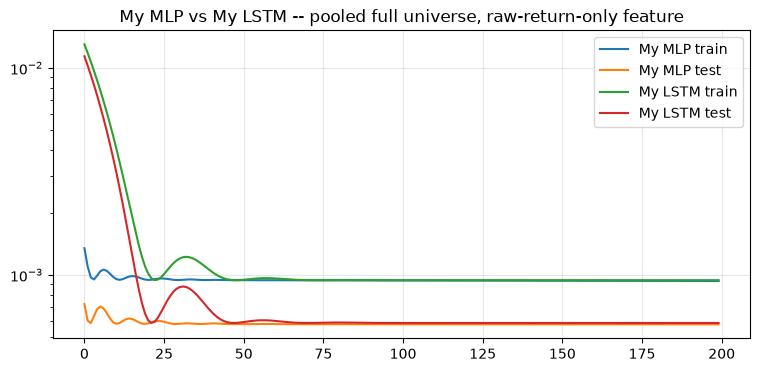

My MLP  final train 0.00094 | test 0.00058
My LSTM final train 0.00094 | test 0.00059


In [12]:
import torch.nn as nn

torch.manual_seed(0)

class MyMLP(nn.Module):
    """Exact architecture from week2/01-day1-neural-network/neural network.ipynb:
    Linear(1,16) -> ReLU -> Linear(16,8) -> ReLU -> Linear(8,1). The only change
    from that notebook is the trailing .squeeze(-1), added so the output shape
    matches train_model's flat-array convention (the same one tradinglab.models.MLP
    already uses) -- it does not change what the network computes."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

MY_EPOCHS = 200   # matches neural network.ipynb / week2/LSTM.ipynb (day3's own EPOCHS=150 is left untouched)

my_mlp = MyMLP()
my_mlp_history = train_model(my_mlp, X_my_train, y_my_train, X_my_test, y_my_test, epochs=MY_EPOCHS)

# tradinglab.models.LSTMRegressor(n_features=1, hidden=16) -- one nn.LSTM layer
# + a Linear(hidden, 1) head -- is architecturally identical to week2/LSTM.ipynb's
# hand-rolled LSTMPredictor(input_size=1, hidden_size=16, num_layers=1), so it's
# reused here rather than redefining the same class a second time.
my_lstm = LSTMRegressor(n_features=1, hidden=16)
my_lstm_history = train_model(my_lstm, Xs_my_train, ys_my_train, Xs_my_test, ys_my_test, epochs=MY_EPOCHS)

plt.figure(figsize=(9, 4))
plt.plot(my_mlp_history['train'], label='My MLP train')
plt.plot(my_mlp_history['test'], label='My MLP test')
plt.plot(my_lstm_history['train'], label='My LSTM train')
plt.plot(my_lstm_history['test'], label='My LSTM test')
plt.yscale('log')
plt.legend(); plt.grid(alpha=.3)
plt.title('My MLP vs My LSTM -- pooled full universe, raw-return-only feature')
plt.show()
print('My MLP  final train %.5f | test %.5f' % (my_mlp_history['train'][-1], my_mlp_history['test'][-1]))
print('My LSTM final train %.5f | test %.5f' % (my_lstm_history['train'][-1], my_lstm_history['test'][-1]))

## 11. My MLP / LSTM as portfolio strategies

Wrapped the same way `model_to_strategy` / `lstm_to_strategy` wrap the
professor's models above: read the last (or last `MY_SEQ_LEN`) day(s) of the
observation, predict, hand the prediction to `predictions_to_weights` -- the
exact same weighting function the professor's strategies use, so portfolio
construction is apples-to-apples. The one difference: my models only ever saw
**one** feature (raw return), so the strategy slices out that single column
instead of passing the whole observation.

**Assumption flagged, as requested:** `src/tradinglab/features.py`'s
`feature_columns` builds `cols = [ret, price/sma_fast - 1, price/sma_slow - 1,
rsi/100, volatility]`, in that order -- so `ret` (raw daily return) is
**column index 0**. `observation.py`'s `build_observation` stacks
`feature_columns` directly with no reordering, so column 0 of the observation
is that same raw return. This was checked against both source files above, not
assumed.

In [13]:
RETURN_COL = 0   # see markdown above -- verified against features.py, not assumed

def my_mlp_to_strategy(model, top_k=TOP_K):
    def strategy(observation):
        feats = observation[:, -1, RETURN_COL:RETURN_COL + 1].astype('float32')   # today's raw return per asset
        preds = predict(model, feats)
        return predictions_to_weights(preds, top_k)
    return strategy


def my_lstm_to_strategy(model, seq_len=MY_SEQ_LEN, top_k=TOP_K):
    def strategy(observation):
        window = observation[:, -seq_len:, RETURN_COL:RETURN_COL + 1].astype('float32')   # last seq_len raw returns per asset
        preds = predict(model, window)
        return predictions_to_weights(preds, top_k)
    return strategy


my_mlp_strategy = my_mlp_to_strategy(my_mlp, top_k=TOP_K)
my_lstm_strategy = my_lstm_to_strategy(my_lstm, seq_len=MY_SEQ_LEN, top_k=TOP_K)

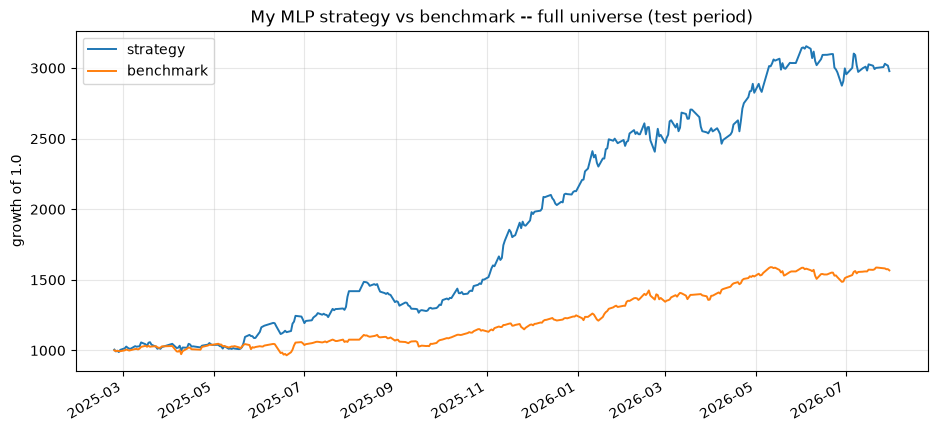

total return   : +197.8%
sharpe         : 3.10
max drawdown   : 14.7%
final value    : 2978.14   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 1,411 EGP


In [14]:
result_my_mlp = run_backtest(sim, my_mlp_strategy, lookback=30, start=split)
report(result_my_mlp, title='My MLP strategy vs benchmark -- full universe (test period)', start_capital=1000.0)

json.dump({'portfolio': [round(x, 4) for x in result_my_mlp['portfolio'].tolist()],
           'benchmark': [round(x, 4) for x in result_my_mlp['benchmark'].tolist()],
           'dates': [d.strftime('%Y-%m-%d') for d in result_my_mlp['dates']]},
          open('dashboard/data/day3_my_mlp_equity.json', 'w'))

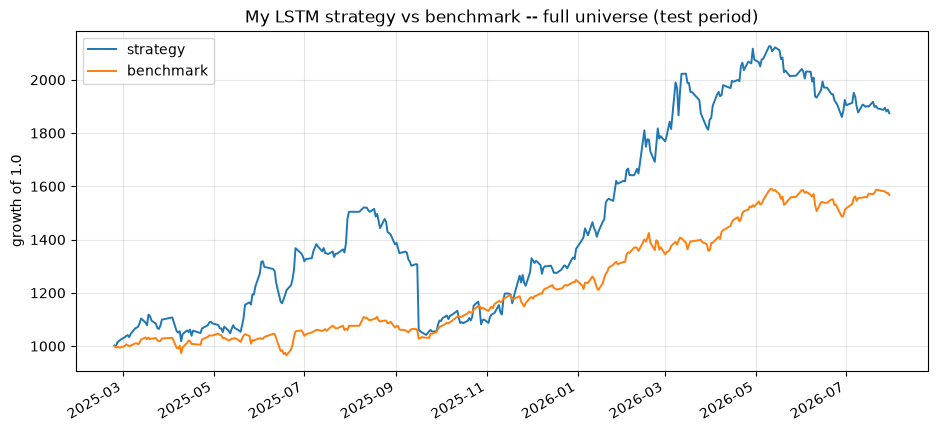

total return   : +87.4%
sharpe         : 1.54
max drawdown   : 31.5%
final value    : 1874.12   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 307 EGP


In [15]:
result_my_lstm = run_backtest(sim, my_lstm_strategy, lookback=30, start=split)
report(result_my_lstm, title='My LSTM strategy vs benchmark -- full universe (test period)', start_capital=1000.0)

json.dump({'portfolio': [round(x, 4) for x in result_my_lstm['portfolio'].tolist()],
           'benchmark': [round(x, 4) for x in result_my_lstm['benchmark'].tolist()],
           'dates': [d.strftime('%Y-%m-%d') for d in result_my_lstm['dates']]},
          open('dashboard/data/day3_my_lstm_equity.json', 'w'))

## 12. The full comparison -- five curves, one chart

My MLP/LSTM (single raw-return feature, single stock's architecture pooled
across the universe) against the professor's MLP/LSTM (full engineered feature
set) against the explicit equal-weight benchmark -- all on the same test
period, same simulator, same `predictions_to_weights` weighting logic.

Color is assigned by **model type** (MLP = blue, LSTM = aqua, benchmark =
orange) so the same architecture is easy to track across "mine" vs "the
professor's"; line style carries **ownership** (solid = mine, dashed =
professor's, dotted = benchmark).

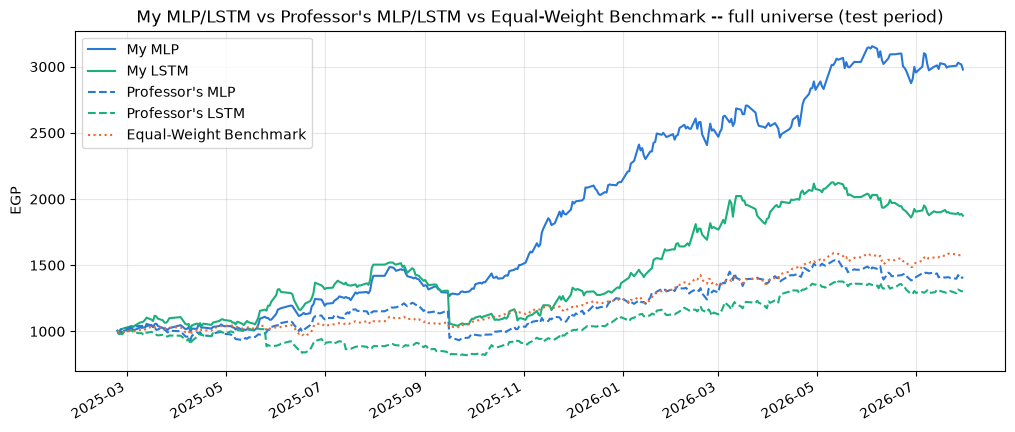

Final EGP ranking (highest first):
 1. My MLP                          2,978 EGP
 2. My LSTM                         1,874 EGP
 3. Equal-Weight Benchmark          1,567 EGP
 4. Professor's MLP                 1,413 EGP
 5. Professor's LSTM                1,304 EGP


In [16]:
plt.figure(figsize=(12, 5))
plt.plot(dates, result_my_mlp['portfolio'] * START, label='My MLP', linestyle='-', color='#2a78d6')
plt.plot(dates, result_my_lstm['portfolio'] * START, label='My LSTM', linestyle='-', color='#1baf7a')
plt.plot(dates, result_mlp['portfolio'] * START, label="Professor's MLP", linestyle='--', color='#2a78d6')
plt.plot(dates, result_lstm['portfolio'] * START, label="Professor's LSTM", linestyle='--', color='#1baf7a')
plt.plot(dates, result_equal_weight['portfolio'] * START, label='Equal-Weight Benchmark', linestyle=':', color='#eb6834')
plt.legend(); plt.grid(alpha=.3); plt.ylabel('EGP')
plt.title("My MLP/LSTM vs Professor's MLP/LSTM vs Equal-Weight Benchmark -- full universe (test period)")
plt.gcf().autofmt_xdate()
plt.show()

finals = {
    'My MLP': result_my_mlp['portfolio'][-1] * START,
    'My LSTM': result_my_lstm['portfolio'][-1] * START,
    "Professor's MLP": result_mlp['portfolio'][-1] * START,
    "Professor's LSTM": result_lstm['portfolio'][-1] * START,
    'Equal-Weight Benchmark': result_equal_weight['portfolio'][-1] * START,
}

print('Final EGP ranking (highest first):')
for rank, (name, value) in enumerate(sorted(finals.items(), key=lambda kv: kv[1], reverse=True), start=1):
    print(f'{rank:2d}. {name:24s} {value:12,.0f} EGP')